In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect("../results/results_am_benchmark.db")

In [3]:
pd.read_sql_query(" SELECT * FROM agent_results LIMIT 5", conn)

,id,agent_name,claim_id,benchmark_name,original_label,model_label,is_correct,total_tokens,prompt_tokens,completion_tokens,time_thought,raw_output,created_at,model_name
0,19213,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,1,am_benchmark,3,1,0,1459,410,1049,18.078153,Ocena prawdziwości wypowiedzi:\n\n1. Pod dwoma...,2026-04-07T20:37:37.131280+00:00,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...
1,19214,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,2,am_benchmark,0,2,0,342,340,2,0.108296,2,2026-04-07T20:37:37.242838+00:00,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...
2,19215,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,3,am_benchmark,3,0,0,1478,273,1205,15.378621,"Wypowiedź odnosi się do węgla kamiennego, któr...",2026-04-07T20:37:52.623660+00:00,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...
3,19216,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,4,am_benchmark,1,1,1,509,371,138,1.820249,"1: Pływy morskie, wiatr, energia słoneczna - s...",2026-04-07T20:37:54.455036+00:00,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...
4,19217,uam_ga1__hf.co-speakleash-Bielik-11B-v2.3-Inst...,5,am_benchmark,3,1,0,1444,318,1126,14.290456,Aby ocenić prawdziwość wypowiedzi dotyczącej r...,2026-04-07T20:38:08.747839+00:00,hf.co/speakleash/Bielik-11B-v2.3-Instruct-GGUF...


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.3)
plt.rcParams['figure.dpi'] = 110

plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
    "figure.titlesize": 16,
})

PALETTE = {'Bielik-11B': '#E07B54', 'llama3.1:8b': '#4C72B0'}

def _short_model(m):
    return 'Bielik-11B' if 'Bielik' in str(m) else 'llama3.1:8b'

# --- uam_ga1 (both models, all 18,820 claims each) ---
ga1 = pd.read_sql_query("""
    SELECT claim_id, is_correct, time_thought, total_tokens,
           prompt_tokens, completion_tokens,
           model_label, original_label, created_at, model_name
    FROM agent_results
    WHERE agent_name LIKE 'uam_ga1__%'
""", conn)
ga1['model']      = ga1['model_name'].apply(_short_model)
ga1['created_at'] = pd.to_datetime(ga1['created_at'], utc=True)

# --- All active agents ga1-ga6 (discontinued web agent 'uam_ga_web_tool_arch' excluded) ---
all_agents = pd.read_sql_query("""
    SELECT agent_name, model_name, claim_id, is_correct,
           time_thought, total_tokens, created_at
    FROM agent_results
    WHERE agent_name NOT LIKE 'uam_ga_web_tool_arch%'
""", conn)
all_agents['model']      = all_agents['model_name'].apply(_short_model)
all_agents['created_at'] = pd.to_datetime(all_agents['created_at'], utc=True)
all_agents['base_agent'] = all_agents['agent_name'].str.extract(r'^(uam_ga\d+)')

# Agent display metadata: label and cost tier
# (renumbered: old web ReAct ga2 discontinued; old ga3-ga7 shifted to ga2-ga6)
AGENT_META = {
    'uam_ga1': ('ga1\nZero-shot',     1),
    'uam_ga2': ('ga2\nBM25',          1),
    'uam_ga3': ('ga3\nRAG+Decomp',    2),
    'uam_ga4': ('ga4\nBM25+Decomp',   2),
    'uam_ga5': ('ga5\nFewShot+RAG',   3),
    'uam_ga6': ('ga6\nDebate',        3),
}
LABEL_ORDER = [v[0] for v in AGENT_META.values()]
all_agents['label'] = all_agents['base_agent'].map(
    lambda x: AGENT_META.get(x, (x, 0))[0])

print(f"ga1: {len(ga1):,} rows | all_agents: {len(all_agents):,} rows")
ga1.groupby('model').agg(
    n=('is_correct', 'count'),
    accuracy_pct=('is_correct', lambda s: round(s.mean() * 100, 1)),
)

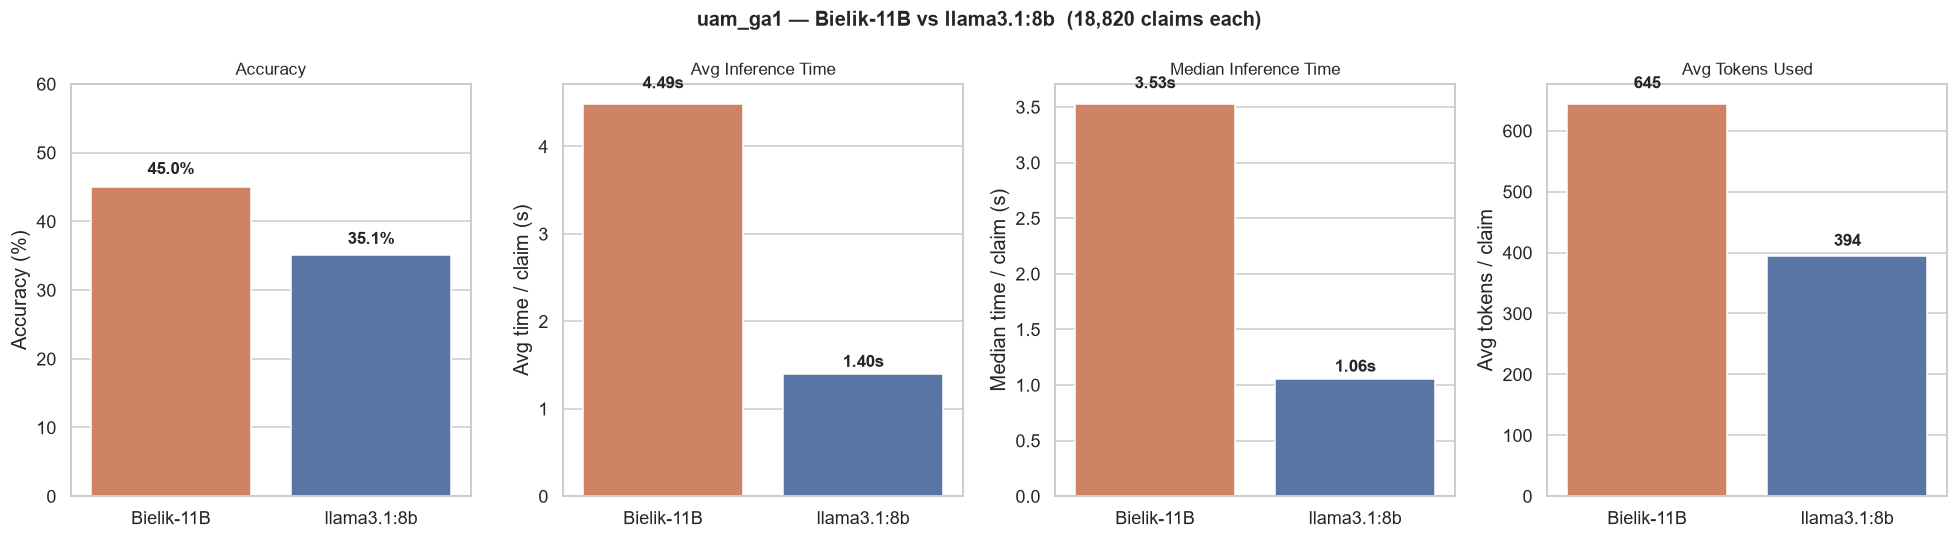

In [5]:
# ── Graph 1 ── uam_ga1: side-by-side model comparison
model_order = ['Bielik-11B', 'llama3.1:8b']
summary_g1 = (
    ga1.groupby('model')
    .agg(accuracy_pct=('is_correct',   lambda s: s.mean() * 100),
         avg_time     =('time_thought', 'mean'),
         median_time  =('time_thought', 'median'),
         avg_tokens   =('total_tokens', 'mean'))
    .loc[model_order]
    .reset_index()
)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('uam_ga1 — Bielik-11B vs llama3.1:8b  (18,820 claims each)',
             fontsize=16, fontweight='bold')

specs = [
    ('accuracy_pct', 'Accuracy (%)',          'Accuracy',             '{:.1f}%', (0, 60)),
    ('avg_time',     'Avg time / claim (s)',   'Avg Inference Time',   '{:.2f}s', None),
    ('median_time',  'Median time / claim (s)','Median Inference Time','{:.2f}s', None),
    ('avg_tokens',   'Avg tokens / claim',     'Avg Tokens Used',      '{:.0f}',  None),
]
for ax, (col, ylabel, title, fmt, ylim) in zip(axes, specs):
    sns.barplot(data=summary_g1, x='model', y=col,
                hue='model', palette=PALETTE, order=model_order,
                errorbar=None, legend=False, ax=ax)
    for container in ax.containers:
        for bar in container:
            if bar is None:
                continue
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.03,
                    fmt.format(h), ha='center', va='bottom',
                    fontweight='bold', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    if ylim:
        ax.set_ylim(*ylim)

plt.tight_layout()
plt.show()


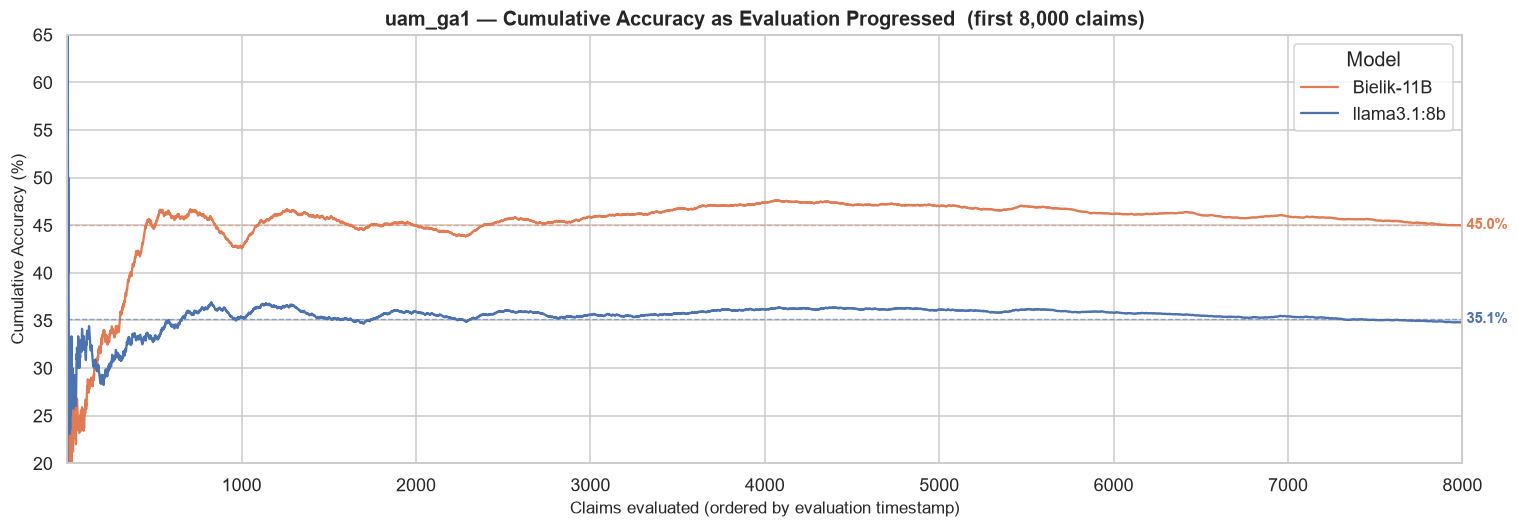

In [6]:
# ── Graph 2 ── Cumulative accuracy over processed claims (first 8,000 — steady-state after that)
CUTOFF = 8000

fig, ax = plt.subplots(figsize=(14, 5))

for model in ['Bielik-11B', 'llama3.1:8b']:
    grp = (ga1[ga1.model == model]
           .sort_values('created_at')
           .reset_index(drop=True))
    grp['cum_acc'] = grp['is_correct'].expanding().mean() * 100
    final          = grp['is_correct'].mean() * 100

    ax.plot(range(1, len(grp) + 1), grp['cum_acc'],
            color=PALETTE[model], linewidth=1.5, label=model)
    ax.axhline(final, color=PALETTE[model], linestyle='--',
               linewidth=0.9, alpha=0.55)
    ax.annotate(f' {final:.1f}%',
                xy=(CUTOFF, final), va='center',
                color=PALETTE[model], fontsize=13, fontweight='bold')

ax.set_xlim(1, CUTOFF)
ax.set_ylim(20, 65)
ax.set_xlabel('Claims evaluated (ordered by evaluation timestamp)', fontsize=14)
ax.set_ylabel('Cumulative Accuracy (%)', fontsize=14)
ax.set_title('uam_ga1 — Cumulative Accuracy as Evaluation Progressed  (first 8,000 claims)',
             fontsize=16, fontweight='bold')
ax.legend(title='Model')
plt.tight_layout()
plt.show()


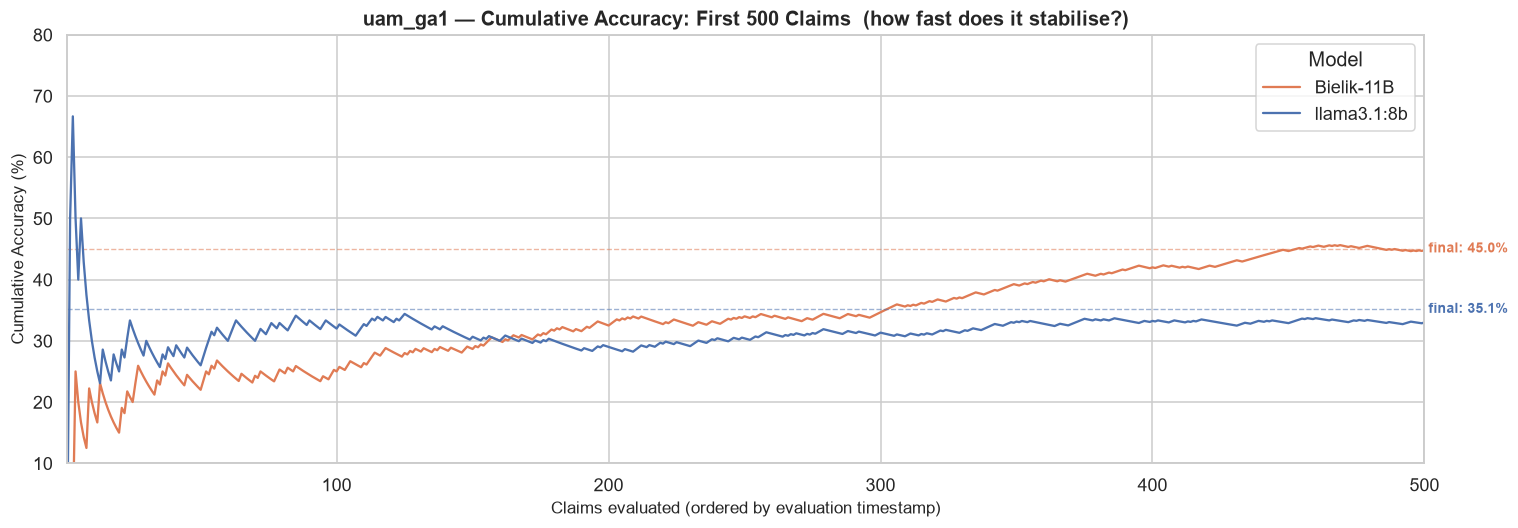

In [7]:
# ── Graph 2a ── Cumulative accuracy — first 500 claims (early stabilization)
EARLY_CUTOFF = 500

fig, ax = plt.subplots(figsize=(14, 5))

for model in ['Bielik-11B', 'llama3.1:8b']:
    grp = (ga1[ga1.model == model]
           .sort_values('created_at')
           .reset_index(drop=True))
    grp['cum_acc'] = grp['is_correct'].expanding().mean() * 100
    final          = grp['is_correct'].mean() * 100

    ax.plot(range(1, len(grp) + 1), grp['cum_acc'],
            color=PALETTE[model], linewidth=1.5, label=model)
    ax.axhline(final, color=PALETTE[model], linestyle='--',
               linewidth=0.9, alpha=0.55)
    ax.annotate(f' final: {final:.1f}%',
                xy=(EARLY_CUTOFF, final), va='center',
                color=PALETTE[model], fontsize=12, fontweight='bold')

ax.set_xlim(1, EARLY_CUTOFF)
ax.set_ylim(10, 80)
ax.set_xlabel('Claims evaluated (ordered by evaluation timestamp)', fontsize=14)
ax.set_ylabel('Cumulative Accuracy (%)', fontsize=14)
ax.set_title('uam_ga1 — Cumulative Accuracy: First 500 Claims  (how fast does it stabilise?)',
             fontsize=16, fontweight='bold')
ax.legend(title='Model')
plt.tight_layout()
plt.show()


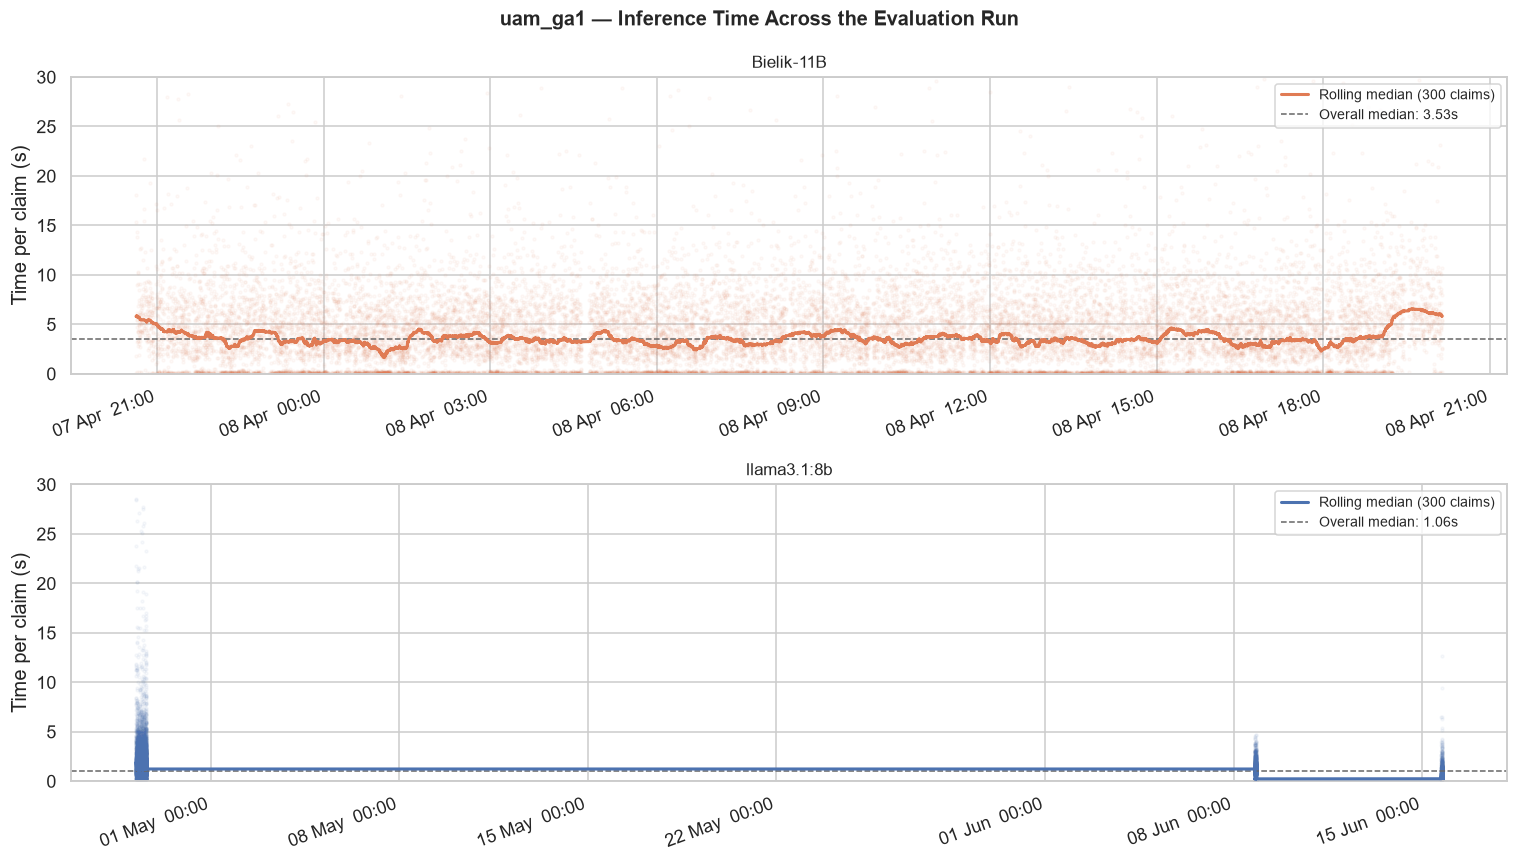

In [8]:
# ── Graph 3 ── Temporal inference time across the evaluation run
# sharey=True enforces the same y-scale on both subplots; ylim clips outliers
Y_CAP = 30  # seconds — captures >99% of claims, clips extreme outliers

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=True)
fig.suptitle('uam_ga1 — Inference Time Across the Evaluation Run',
             fontsize=16, fontweight='bold')

for i, model in enumerate(['Bielik-11B', 'llama3.1:8b']):
    grp = (ga1[ga1.model == model]
           .sort_values('created_at')
           .reset_index(drop=True))
    roll_med    = grp['time_thought'].rolling(300, center=True, min_periods=20).median()
    overall_med = grp['time_thought'].median()

    axes[i].scatter(grp['created_at'], grp['time_thought'],
                    alpha=0.04, color=PALETTE[model], s=4, rasterized=True)
    axes[i].plot(grp['created_at'], roll_med,
                 color=PALETTE[model], linewidth=2,
                 label='Rolling median (300 claims)', zorder=5)
    axes[i].axhline(overall_med, color='#666', linestyle='--', linewidth=1,
                    label=f'Overall median: {overall_med:.2f}s')
    axes[i].set_title(model, fontsize=14)
    axes[i].set_ylabel('Time per claim (s)')
    axes[i].legend(loc='upper right', fontsize=12)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%d %b  %H:%M'))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=20, ha='right')

axes[0].set_ylim(0, Y_CAP)  # applies to both via sharey
plt.tight_layout()
plt.show()


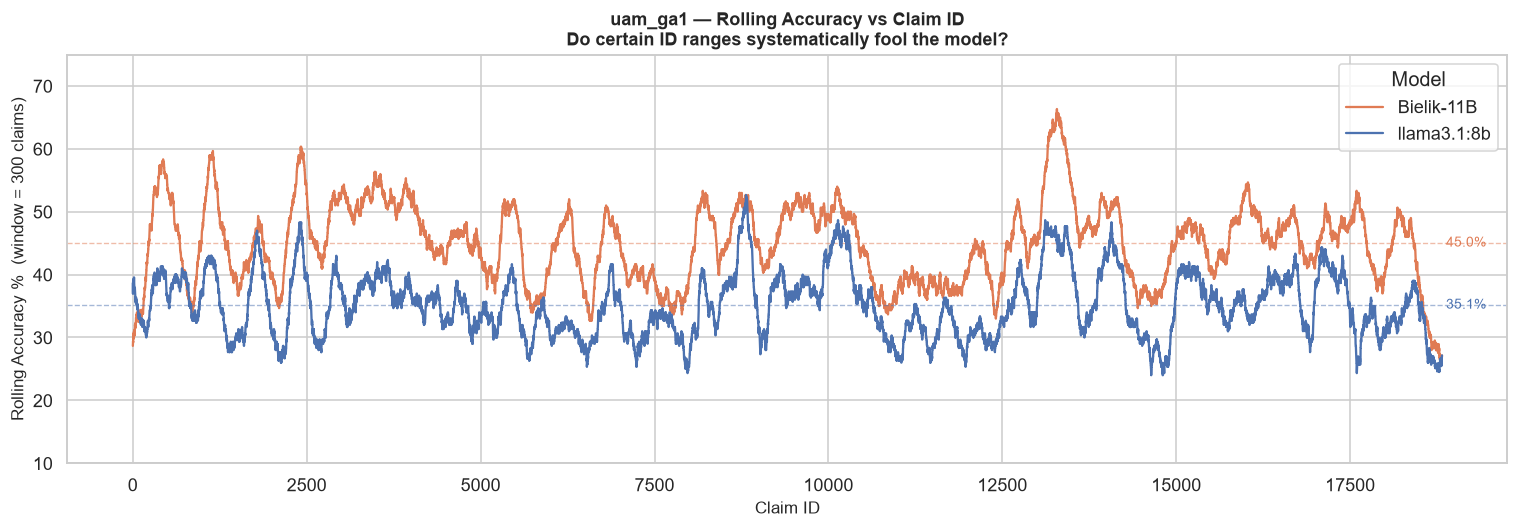

In [9]:
# ── Graph 4 ── Rolling accuracy vs claim ID
WINDOW = 300

fig, ax = plt.subplots(figsize=(14, 5))

for model in ['Bielik-11B', 'llama3.1:8b']:
    grp = (ga1[ga1.model == model]
           .sort_values('claim_id')
           .reset_index(drop=True))
    roll    = grp['is_correct'].rolling(WINDOW, center=True, min_periods=50).mean() * 100
    overall = grp['is_correct'].mean() * 100

    ax.plot(grp['claim_id'], roll,
            color=PALETTE[model], linewidth=1.5, label=model)
    ax.axhline(overall, color=PALETTE[model],
               linestyle='--', linewidth=0.9, alpha=0.5)
    ax.annotate(f' {overall:.1f}%',
                xy=(grp['claim_id'].max(), overall),
                va='center', color=PALETTE[model], fontsize=12)

ax.set_xlabel('Claim ID', fontsize=14)
ax.set_ylabel(f'Rolling Accuracy %  (window = {WINDOW} claims)', fontsize=14)
ax.set_title('uam_ga1 — Rolling Accuracy vs Claim ID\n'
             'Do certain ID ranges systematically fool the model?',
             fontsize=15, fontweight='bold')
ax.set_ylim(10, 75)
ax.legend(title='Model')
plt.tight_layout()
plt.show()


In [ ]:
# ── Graph 5 ── Agent complexity: accuracy & efficiency frontier
agent_summary = (
    all_agents
    .groupby(['base_agent', 'model', 'label'])
    .agg(
        accuracy_pct=('is_correct',   lambda s: s.mean() * 100),
        median_time =('time_thought', 'median'),
        avg_tokens  =('total_tokens', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('All Agents (ga1–ga6) — Accuracy & Efficiency by Complexity',
             fontsize=16, fontweight='bold')

# -- Left: accuracy bars --
sns.barplot(data=agent_summary, x='label', y='accuracy_pct', hue='model',
            palette=PALETTE, order=LABEL_ORDER, errorbar=None, ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)
axes[0].set_ylim(0, 62)
axes[0].set_title('Accuracy by Agent & Model', fontsize=14)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Agent  →  increasing complexity')
axes[0].tick_params(axis='x', labelsize=12)
axes[0].legend(title='Model', fontsize=12)
for x in (2.5, 4.5):
    axes[0].axvline(x, color='grey', linewidth=0.8, linestyle=':')
for x, lbl in ((1.0, 'Tier 1'), (3.5, 'Tier 2'), (5.0, 'Tier 3')):
    axes[0].text(x, 59.5, lbl, ha='center', fontsize=11, color='grey')

# -- Right: accuracy vs median time scatter (bubble size ∝ avg tokens) --
for _, row in agent_summary.iterrows():
    axes[1].scatter(row['median_time'], row['accuracy_pct'],
                    color=PALETTE[row['model']],
                    s=row['avg_tokens'] / 40,
                    alpha=0.85, edgecolors='white', linewidth=0.8, zorder=5)
    axes[1].annotate(row['label'].replace('\n', ' '),
                     xy=(row['median_time'], row['accuracy_pct']),
                     xytext=(6, 3), textcoords='offset points',
                     fontsize=11.5, color='#333')

legend_handles = [Line2D([0],[0], marker='o', color='w',
                         markerfacecolor=c, markersize=11, label=m)
                  for m, c in PALETTE.items()]
axes[1].legend(handles=legend_handles, title='Model', fontsize=12)
axes[1].set_xlabel('Median Inference Time (s)', fontsize=14)
axes[1].set_ylabel('Accuracy (%)', fontsize=14)
axes[1].set_title('Efficiency Frontier\n(bubble size ∝ avg tokens per claim)', fontsize=14)
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()


In [ ]:
# ── Graph 6 ── Per-claim distributions: inference time & tokens
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Per-claim Distributions — Inference Time & Token Usage  (ga1–ga6)',
             fontsize=16, fontweight='bold')

bp_kwargs = dict(order=LABEL_ORDER, palette=PALETTE, showfliers=False)

sns.boxplot(data=all_agents, x='label', y='time_thought',
            hue='model', ax=axes[0], **bp_kwargs)
axes[0].set_title('Inference Time  (outliers excluded)', fontsize=14)
axes[0].set_ylabel('Time per claim (s)')
axes[0].set_xlabel('Agent  →  increasing complexity')
axes[0].tick_params(axis='x', labelsize=12)
axes[0].legend(title='Model', fontsize=12)

sns.boxplot(data=all_agents, x='label', y='total_tokens',
            hue='model', ax=axes[1], **bp_kwargs)
axes[1].set_yscale('log')
axes[1].set_title('Token Usage  (log scale, outliers excluded)', fontsize=14)
axes[1].set_ylabel('Tokens per claim  (log scale)')
axes[1].set_xlabel('Agent  →  increasing complexity')
axes[1].tick_params(axis='x', labelsize=12)
axes[1].legend(title='Model', fontsize=12)

plt.tight_layout()
plt.show()


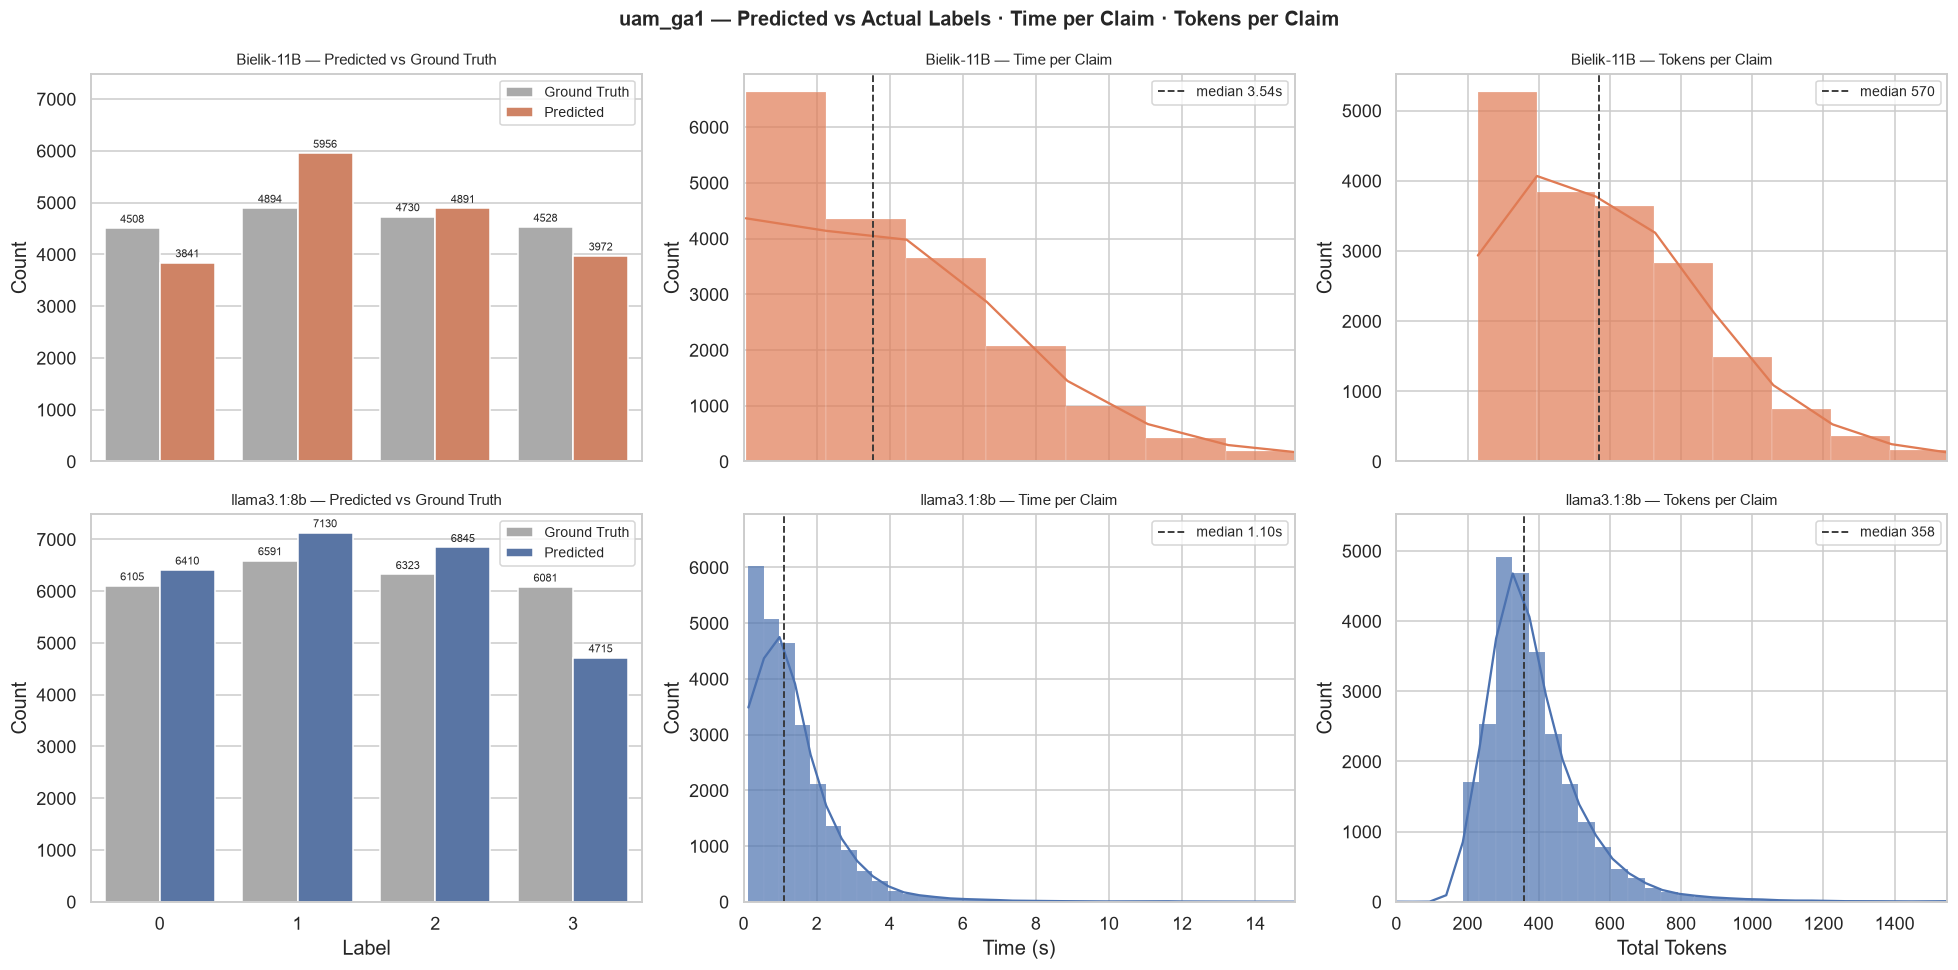

In [12]:
# ── Graph 7 ── Label distributions, time per claim & tokens per claim  (2 × 3 grid)
valid_labels = ['0', '1', '2', '3']
ga1_valid = ga1[ga1['model_label'].isin(valid_labels)].copy()

# Shared axis limits (computed across both models so scales are identical)
p99_time   = ga1_valid['time_thought'].quantile(0.99)
p99_tokens = ga1_valid['total_tokens'].quantile(0.99)

fig, axes = plt.subplots(2, 3, figsize=(18, 9),
                         sharex='col', sharey='col')
fig.suptitle('uam_ga1 — Predicted vs Actual Labels · Time per Claim · Tokens per Claim',
             fontsize=16, fontweight='bold')

for row, model in enumerate(['Bielik-11B', 'llama3.1:8b']):
    grp   = ga1_valid[ga1_valid.model == model]
    color = PALETTE[model]

    # ── Col 0: label distribution — ground truth vs predicted ──
    label_df = pd.concat([
        grp['original_label'].rename('label').to_frame().assign(source='Ground Truth'),
        grp['model_label'].rename('label').to_frame().assign(source='Predicted'),
    ], ignore_index=True)
    sns.countplot(data=label_df, x='label', hue='source',
                  order=valid_labels,
                  palette={'Ground Truth': '#aaaaaa', 'Predicted': color},
                  ax=axes[row, 0])
    axes[row, 0].set_title(f'{model} — Predicted vs Ground Truth', fontsize=13)
    axes[row, 0].set_xlabel('Label')
    axes[row, 0].set_ylabel('Count')
    axes[row, 0].legend(title='', fontsize=12)
    for container in axes[row, 0].containers:
        axes[row, 0].bar_label(container, fmt='%d', padding=2, fontsize=8)

    # ── Col 1: time per claim histogram ──
    sns.histplot(data=grp, x='time_thought', bins=200, kde=True,
                 color=color, alpha=0.7, ax=axes[row, 1])
    axes[row, 1].axvline(grp['time_thought'].median(), color='#333', linewidth=1.2,
                         linestyle='--', label=f'median {grp["time_thought"].median():.2f}s')
    axes[row, 1].set_title(f'{model} — Time per Claim', fontsize=13)
    axes[row, 1].set_xlabel('Time (s)')
    axes[row, 1].set_ylabel('Count')
    axes[row, 1].legend(fontsize=12)

    # ── Col 2: tokens per claim histogram ──
    sns.histplot(data=grp, x='total_tokens', bins=200, kde=True,
                 color=color, alpha=0.7, ax=axes[row, 2])
    axes[row, 2].axvline(grp['total_tokens'].median(), color='#333', linewidth=1.2,
                         linestyle='--', label=f'median {grp["total_tokens"].median():.0f}')
    axes[row, 2].set_title(f'{model} — Tokens per Claim', fontsize=13)
    axes[row, 2].set_xlabel('Total Tokens')
    axes[row, 2].set_ylabel('Count')
    axes[row, 2].legend(fontsize=12)

# Apply shared x limits after both rows are drawn (sharex propagates to both rows)
axes[0, 1].set_xlim(0, p99_time)
axes[0, 2].set_xlim(0, p99_tokens)

# Shared axis: remove redundant x-tick labels on top row
for col in range(3):
    axes[0, col].tick_params(labelbottom=False)

plt.tight_layout()
plt.show()


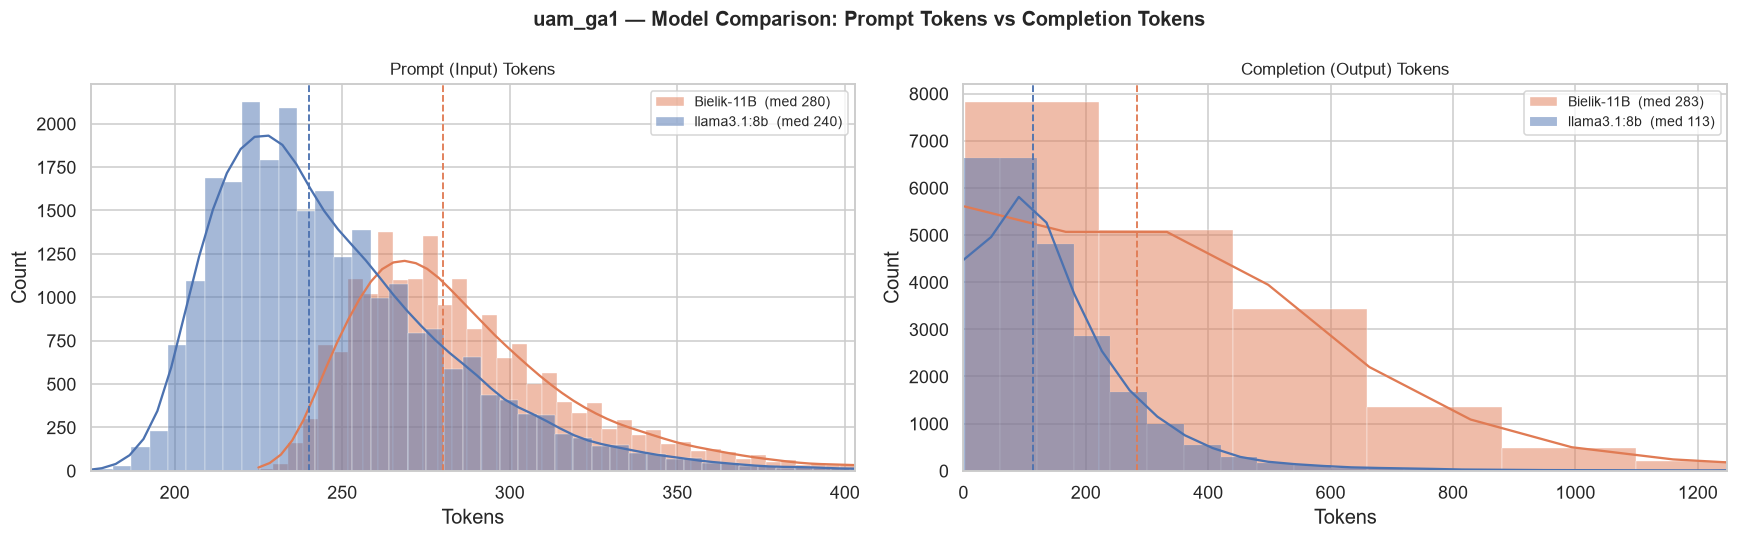

In [13]:
# ── Graph 8 ── Prompt vs Completion tokens: Bielik vs llama
# Thickness = variance: wide distribution means the model's output length varies
# wildly across claims; narrow = consistently similar length every time.
p99_prompt     = ga1_valid['prompt_tokens'].quantile(0.99)
p99_completion = ga1_valid['completion_tokens'].quantile(0.99)

XLIMS = {
    'prompt_tokens':     (175, p99_prompt),      # cut left tail (fixed system prompt floor)
    'completion_tokens': (0,   p99_completion),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('uam_ga1 — Model Comparison: Prompt Tokens vs Completion Tokens',
             fontsize=16, fontweight='bold')

for col, (token_col, title) in enumerate([
    ('prompt_tokens',     'Prompt (Input) Tokens'),
    ('completion_tokens', 'Completion (Output) Tokens'),
]):
    ax = axes[col]
    for model in ['Bielik-11B', 'llama3.1:8b']:
        grp = ga1_valid[ga1_valid.model == model]
        med = grp[token_col].median()
        sns.histplot(data=grp, x=token_col, bins=150, kde=True,
                     color=PALETTE[model], alpha=0.5,
                     label=f'{model}  (med {med:.0f})', ax=ax)
        ax.axvline(med, color=PALETTE[model], linewidth=1.2, linestyle='--')

    ax.set_xlim(*XLIMS[token_col])
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Count')
    ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
pd.read_sql_query("""
    SELECT
        agent_name,
        model_name,
        COUNT(*)                                                        AS n,
        ROUND(100.0 * SUM(is_correct) / COUNT(*), 2)                   AS accuracy_pct,
        SUM(total_tokens)                                               AS total_tokens,
        ROUND(AVG(prompt_tokens), 1)                                    AS avg_prompt_tokens,
        ROUND(AVG(completion_tokens), 1)                                AS avg_completion_tokens,
        ROUND(AVG(time_thought), 3)                                     AS avg_time_s,
        ROUND(AVG(time_thought) / NULLIF(AVG(total_tokens), 0), 6)     AS avg_time_per_token,
        ROUND(SUM(total_tokens) / NULLIF(SUM(is_correct), 0), 1)       AS tokens_per_correct
    FROM agent_results
    GROUP BY agent_name, model_name
    ORDER BY agent_name, model_name
""", conn)

## Benchmark Dimensions — Topic, Year, Label Balance, Position Bias
Full-benchmark models (Bielik-11B & llama3.1:8b on all 18,820 claims) joined to benchmark metadata from `data/benchmarks/am_benchmark.db`.

In [ ]:
import re, json
bench_conn = sqlite3.connect("../data/benchmarks/am_benchmark.db")
claims = pd.read_sql_query(
    "SELECT id AS claim_id, topic, claim_date, label_original, metadata FROM claims",
    bench_conn)

def _topic_family(t):
    t = str(t)
    m = re.match(r"^([A-Za-z]+)\.\d", t)
    return (m.group(1).upper() + " (exam code)") if m else t

def _correct_idx(meta):
    try:
        return json.loads(meta).get("correct_answer_index")
    except Exception:
        return None

claims["topic_family"] = claims["topic"].apply(_topic_family)
claims["year"]         = pd.to_numeric(claims["claim_date"], errors="coerce")
claims["correct_idx"]  = claims["metadata"].apply(_correct_idx)

dims = claims[["claim_id", "topic", "topic_family", "year", "correct_idx"]]
ad = all_agents.merge(dims, on="claim_id", how="left")            # ga1-ga6
g1 = ga1.merge(dims.assign(label_original=claims["label_original"]),
               on="claim_id", how="left")                          # ga1, both models
print(f"joined: all_agents {ad.shape}, ga1 {g1.shape}")

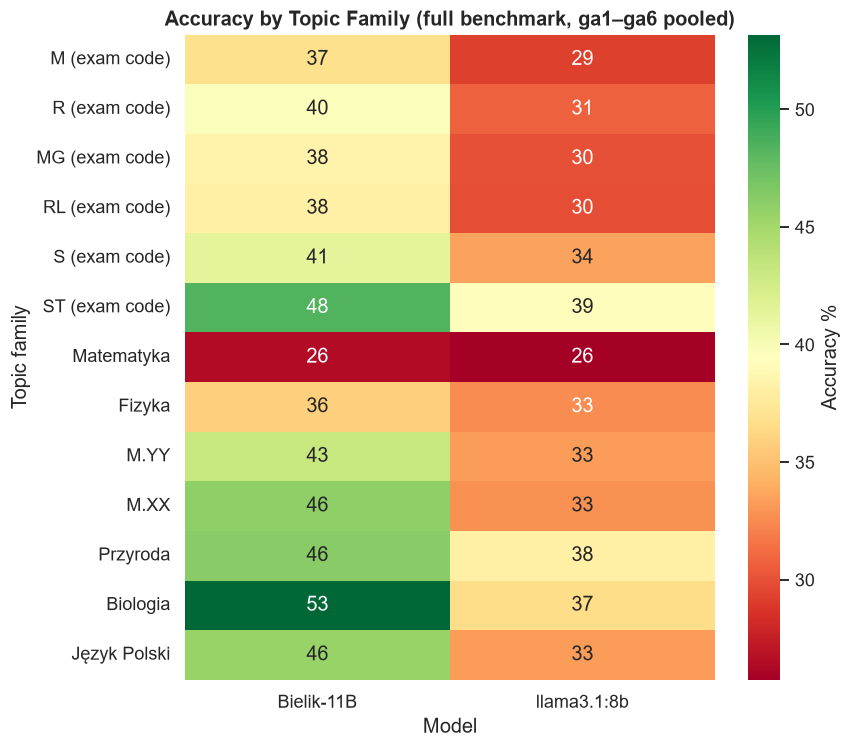

In [16]:
# Accuracy by topic family (full benchmark, ga1-ga6 pooled)
fam = (ad.pivot_table("is_correct", "topic_family", "model", "mean") * 100)
fam_n = ad[ad.model == "Bielik-11B"].groupby("topic_family")["claim_id"].nunique()
fam = fam.assign(n=fam_n).sort_values("n", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(fam[["Bielik-11B", "llama3.1:8b"]], annot=True, fmt=".0f", cmap="RdYlGn",
            cbar_kws={"label": "Accuracy %"}, ax=ax)
ax.set_title("Accuracy by Topic Family (full benchmark, ga1–ga6 pooled)", fontweight="bold")
ax.set_ylabel("Topic family"); ax.set_xlabel("Model")
plt.tight_layout(); plt.show()

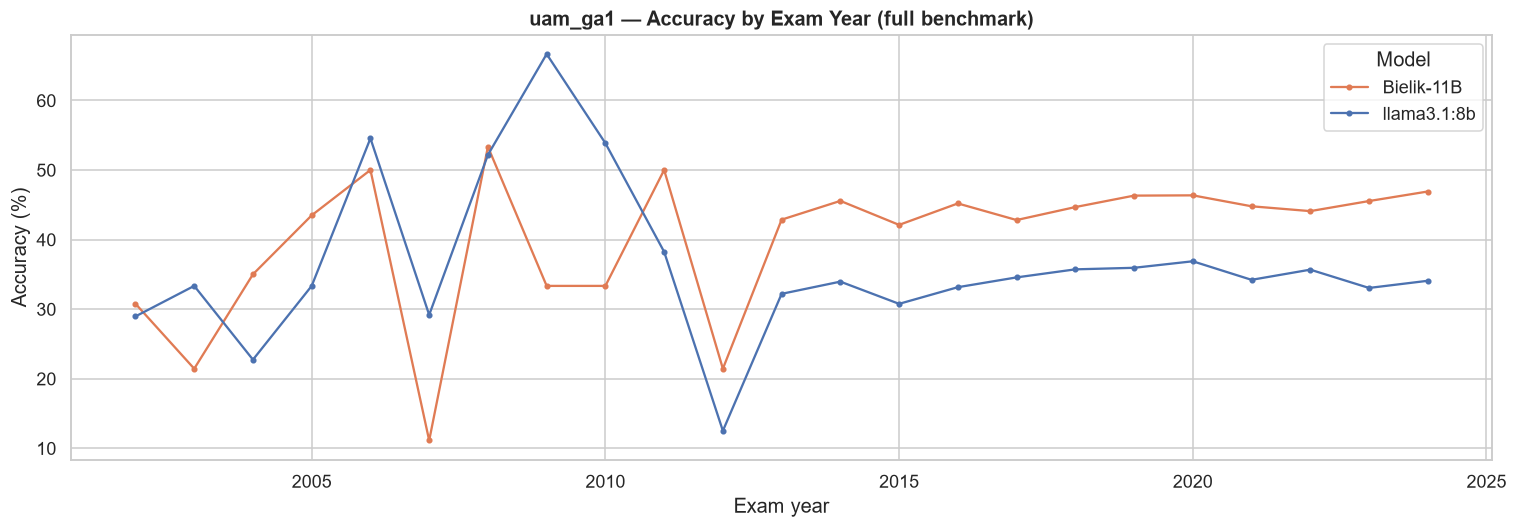

In [17]:
# Accuracy by exam year (uam_ga1, full benchmark)
yr = (g1.dropna(subset=["year"]).pivot_table("is_correct", "year", "model", "mean") * 100)
fig, ax = plt.subplots(figsize=(14, 5))
for m in ["Bielik-11B", "llama3.1:8b"]:
    if m in yr:
        ax.plot(yr.index, yr[m], marker="o", ms=3, color=PALETTE[m], label=m)
ax.set_title("uam_ga1 — Accuracy by Exam Year (full benchmark)", fontweight="bold")
ax.set_xlabel("Exam year"); ax.set_ylabel("Accuracy (%)"); ax.legend(title="Model")
plt.tight_layout(); plt.show()

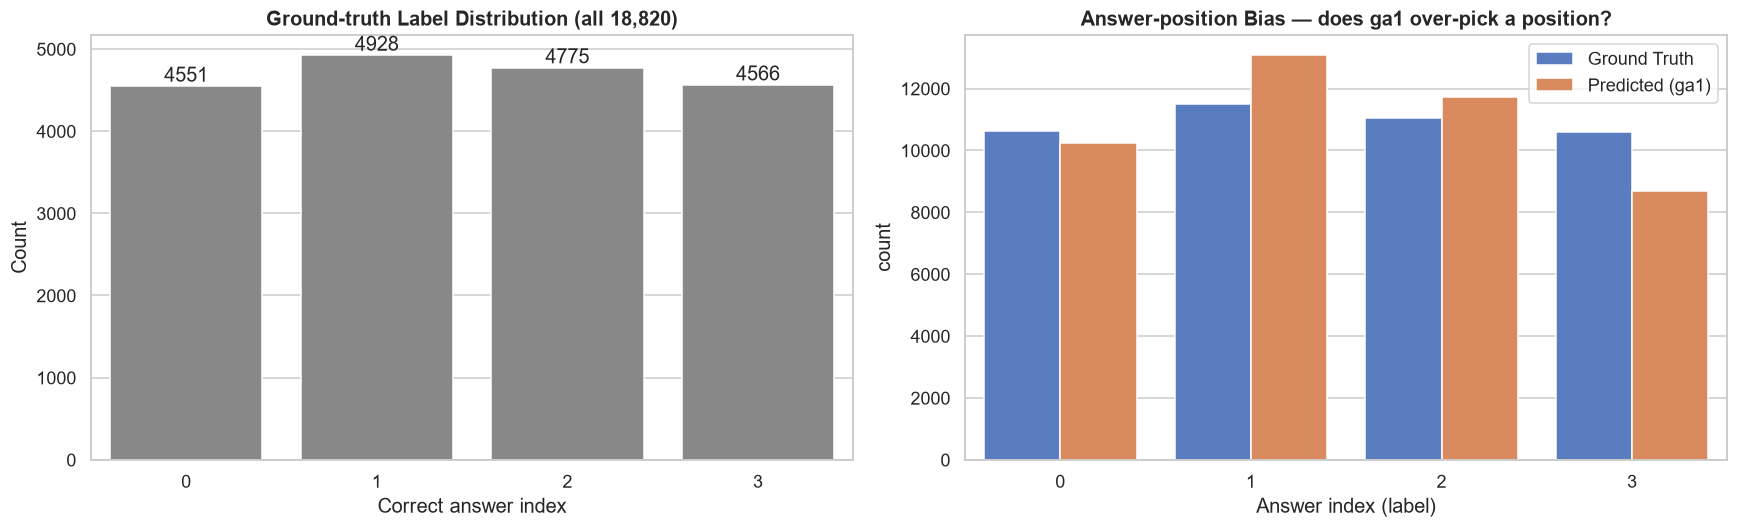

In [18]:
# Benchmark label balance + answer-position bias (uam_ga1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

gt = claims["label_original"].astype(str).value_counts().sort_index()
sns.barplot(x=gt.index, y=gt.values, ax=axes[0], color="#888")
axes[0].set_title("Ground-truth Label Distribution (all 18,820)", fontweight="bold")
axes[0].set_xlabel("Correct answer index"); axes[0].set_ylabel("Count")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d")

g1v = g1[g1.model_label.isin(["0", "1", "2", "3"])]
pos = pd.concat([
    g1v["original_label"].astype(str).rename("label").to_frame().assign(src="Ground Truth"),
    g1v["model_label"].astype(str).rename("label").to_frame().assign(src="Predicted (ga1)"),
], ignore_index=True)
sns.countplot(data=pos, x="label", hue="src", order=["0", "1", "2", "3"], ax=axes[1])
axes[1].set_title("Answer-position Bias — does ga1 over-pick a position?", fontweight="bold")
axes[1].set_xlabel("Answer index (label)"); axes[1].legend(title="")
plt.tight_layout(); plt.show()

**Notes for thesis:**
- Topic families (exam-code R./M./… vs named subjects) differ in difficulty — see heatmap.
- Watch for accuracy drift across exam years (curriculum/era effects).
- Ground-truth labels are imbalanced; compare to the predicted-label distribution to detect position bias (models over-picking a particular answer index).